In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/cleaned_insurance_data.csv")

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin,HasClaim
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825,0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825,0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000,0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070,0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000,0


## Target Variable Understanding

We are predicting `TotalClaims`, which represents the severity of insurance claims.

This is a regression problem because the target variable is continuous (monetary value).

In [3]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'CrossBorder',
       'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency',
       'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory',
       'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass',
       'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'LossRatio',
       'Margin', 'HasClaim'],
      dtype='str')

In [4]:
df["TotalClaims"].describe()

count    1.000098e+06
mean     6.486119e+01
std      2.384075e+03
min     -1.200241e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.930921e+05
Name: TotalClaims, dtype: float64

In [5]:
df_claims = df[df["TotalClaims"] > 0]
df_claims.shape

(2788, 51)

In [6]:
df_claims.head()
df_claims["TotalClaims"].describe()

count      2788.000000
mean      23273.387063
std       38719.512597
min         139.043860
25%        1680.728070
50%        6140.350877
75%       30480.991228
max      393092.105263
Name: TotalClaims, dtype: float64

In [7]:
df_claims["VehicleAge"] = 2026 - df_claims["RegistrationYear"]

In [8]:
df_claims["PremiumToInsuredRatio"] = (
    df_claims["TotalPremium"] / df_claims["SumInsured"]
)

In [9]:
df_claims["ClaimRatio"] = (
    df_claims["TotalClaims"] / df_claims["TotalPremium"]
)

In [10]:
features = [
    "Province",
    "VehicleType",
    "make",
    "Gender",
    "SumInsured",
    "CalculatedPremiumPerTerm",
    "CustomValueEstimate",
    "VehicleAge",
    "kilowatts",
    "cubiccapacity"
]

In [11]:
X = df_claims[features]
y = df_claims["TotalClaims"]

In [12]:
categorical_cols = X.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Linear Regression Model

- **Model type**: `LinearRegression()` with default parameters.  
- **Key settings**: Intercept fitted (`fit_intercept=True`), no positivity constraint.  
- **Tolerance**: `1e-06` for optimization convergence.  

Model is ready for training; no custom hyperparameters were specified.

In [15]:
lr_preds = lr_model.predict(X_test)

In [16]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print(lr_rmse, lr_r2)

37067.78955561004 0.1456410754051639


## Linear Regression Performance

- **RMSE**: 37,067.79  
- **R²**: 0.146  

The model explains only ~14.6% of the variance, indicating poor fit. High prediction error suggests linear regression may not be suitable for this data.

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Random Forest Regressor – Parameters

- **Trees**: 100 estimators  
- **Criterion**: Squared error  
- **Max depth**: None (nodes expand until all leaves are pure)  
- **Min samples split**: 2  
- **Min samples leaf**: 1  
- **Max features**: 1.0 (all features considered)  
- **Bootstrap**: Enabled  
- **Random state**: 42 (for reproducibility)  

Default settings used, with a fixed seed for consistent results.

In [18]:
rf_preds = rf_model.predict(X_test)

In [19]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

In [20]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## XGBoost Regressor – Parameters

- **n_estimators**: 100  
- **learning_rate**: 0.1  
- **max_depth**: 6  
- **objective**: reg:squarederror  
- **random_state**: 42  

Other parameters use defaults. Model is configured for standard regression with moderate tree depth and learning rate.

In [21]:
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

In [22]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,37067.789556,0.145641
1,Random Forest,36335.939009,0.179044
2,XGBoost,36780.193067,0.158847


### 🔍 Interpretation

- The **Random Forest model** achieved the best overall performance among the tested models.
- It produced the **lowest RMSE**, indicating better prediction accuracy with smaller average prediction errors.
- It also achieved the **highest R² score**, meaning it explained more variability in insurance claim amounts compared to the other models.

###  Key Insights

- Insurance claim severity appears to involve **complex non-linear relationships**, which tree-based models like Random Forest can capture more effectively than Linear Regression.
- The relatively low R² scores suggest that claim severity is influenced by additional factors not fully captured in the current dataset.
- Despite this limitation, the models still provide useful insights for **risk-based pricing and underwriting decisions**.

###  Conclusion

Based on the evaluation metrics, the **Random Forest model** was selected as the preferred model for claim severity prediction in this project.

In [23]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df.head(10)

,Feature,Importance
5,CalculatedPremiumPerTerm,0.376171
4,SumInsured,0.278663
6,CustomValueEstimate,0.085138
7,VehicleAge,0.059355
8,kilowatts,0.050300
0,Province,0.045970
9,cubiccapacity,0.043778
1,VehicleType,0.028702
2,make,0.025324
3,Gender,0.006599


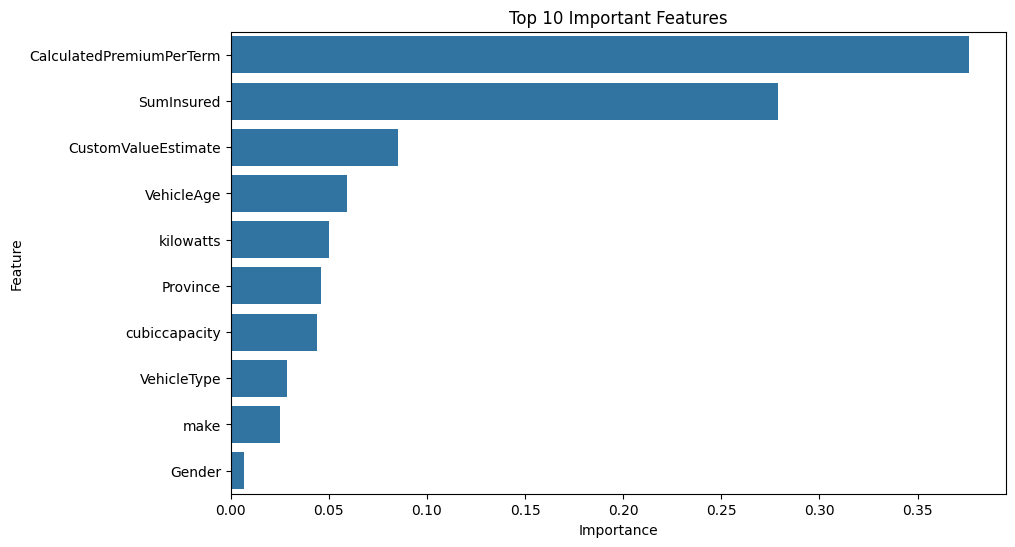

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

## Top 10 Important Features (Random Forest)

- **CalculatedPremiumPerTerm** is the most influential feature by a large margin.  
- **SumInsured** and **CustomValueEstimate** also show strong importance.  
- Vehicle attributes (age, kilowatts, cubic capacity, type, make) and **Province** contribute moderately.  
- **Gender** has the lowest importance among the top 10.  

Premium-related and vehicle value features drive predictions most significantly.

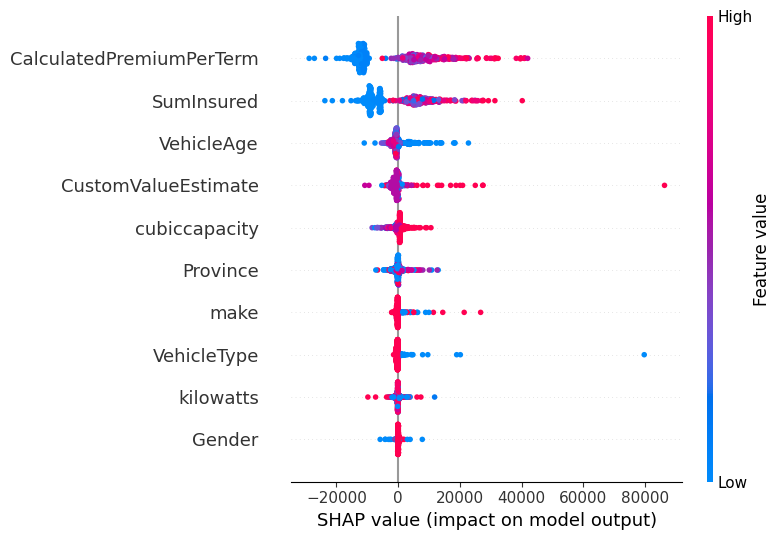

In [25]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## SHAP Feature Importance Summary

- **CalculatedPremiumPerTerm** has the highest impact and widest SHAP value range.  
- **SumInsured** and **VehicleAge** also show strong influence on model output.  
- **Gender** has the lowest overall impact.  
- Red/blue coloring indicates high/low feature values — e.g., high `CalculatedPremiumPerTerm` generally increases predictions.  

The model relies heavily on premium, insured amount, and vehicle age.

# * Conclusion

This project developed predictive models for estimating insurance claim severity using historical insurance data.

Among the evaluated models, the Random Forest model achieved the best predictive performance, demonstrating the ability of ensemble learning methods to capture complex non-linear relationships within insurance risk data.

Feature importance and SHAP analysis revealed that insured value, vehicle age, and premium-related variables are among the most influential factors affecting claim severity.

The findings support the implementation of risk-based pricing strategies and data-driven underwriting decisions within insurance operations.

# * Recommendations

- Implement risk-based premium pricing using predictive modeling outputs.
- Pay closer attention to high-risk vehicle categories and older vehicles.
- Improve data collection by incorporating additional customer behavioral and driving-related variables.
- Continuously retrain models using updated claims data to improve predictive performance.
- Use explainable AI techniques such as SHAP to improve transparency and trust in automated pricing decisions.

# * Limitations

- The dataset may not capture all factors influencing insurance claim severity.
- Some variables contained missing or limited information.
- The relatively low R² scores indicate that additional predictive features may be required for stronger performance.
- External economic and environmental factors were not included in the analysis.

# Future Work

Future improvements could include:

- Incorporating driver behavior and telematics data.
- Experimenting with advanced boosting algorithms and deep learning models.
- Performing hyperparameter tuning for improved accuracy.
- Building separate models for different insurance product categories.
- Deploying the model as a real-time insurance pricing API.